# Plotting notebook for geophysics
This notebook extracts and plots the geophysics compilation table. The steps are as follows:
- 1. Import dependencies and install packages
- 2. Import compilation
- 3. plot compilation

## 1. Import packages and setup folders and paths

### Install packages if not installed

In [1]:
#%pip install --upgrade DiadFit
#%pip install Thermobar

### Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import DiadFit as pf
import os
import pickle

mpl.rcParams['pdf.fonttype'] = 42  # 42 is for TrueType fonts

### Setup folders and data paths

In [3]:
# This is to make sure the code runs regardless of operating system
if os.name=='posix':
    slash='/'
else:
    slash='\\'

# Set master folder
MasterFolder=os.path.dirname(os.getcwd())

#Folder to save figures

figpath=MasterFolder +slash+"Plotting_notebooks"+slash+'Notebook_Figs'
if not os.path.exists(figpath):
    os.mkdir(figpath)
# Create folder to save full datasets

compilation_folder=MasterFolder +slash+"Plotting_notebooks"+slash+'Notebook_Compiled_data'
if not os.path.exists(compilation_folder):
    os.mkdir(compilation_folder)

## 2. Import all datasets

### Import geophysics compilation

In [4]:
geophysics=pd.read_excel(MasterFolder +slash+'geophysics compilation_2Dec25.xlsx') # has the explanation row. Unecessary after this
geophysics = geophysics.drop(index=0)
geophysics.head(1)

,Reference Study,Publication year,Ref short,Activity,"Main Geophysical method (Deformation, Seismic, Gravity, Resistivity, Electromagnetic)",Study type,Deformation source geometry,Source #,"Region (SC, HM, K, ERZ, SWRZ)",Time Period (month/year or year),Reservoir locations,"Depth measured, inferred, external (M or I,E)","Reservoir depth is a range (R ), mean (A), best-fit (B), Best-fit MCMC (BMC)",Depth (km),Depth uncertainty left (-km),Depth uncertainty right (+km),Cumulate upper depth (km),Cumulate lower depth (km),Comments
1,Mogi [1958],1958,M58,"Deflation of summit related to 1924 eruption, ...",Deformation,"Tilt, triangulation; Point source",Point source,1,SC,1912-1927,1-2 km S of Halema'uma'u,M,B,3.5,1,1,NaN,NaN,"Assumed spherical source, visual matching of t..."


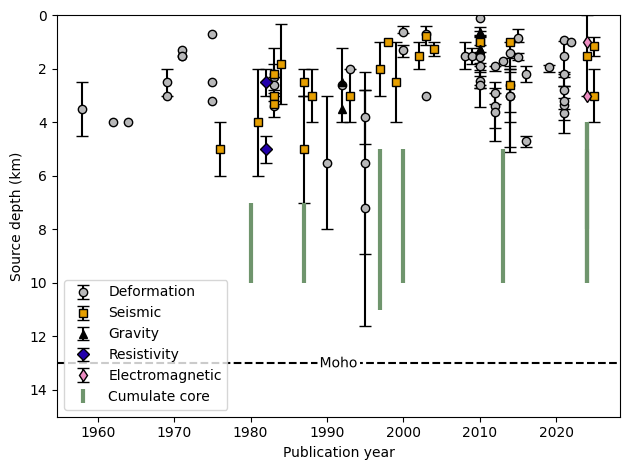

In [5]:
methods = ['Deformation', 'Seismic', 'Gravity', 'Resistivity', 'Electromagnetic']
colors = ["#B8B8B9", '#E69F00', "#000000", "#2200AB", "#ED8DC2"]
markers = ['o', 's', '^', 'D', 'd','*'] 

for method, color,marker in zip(methods, colors, markers):
    mask = geophysics['Main Geophysical method (Deformation, Seismic, Gravity, Resistivity, Electromagnetic)'].str.contains(method, na=False)

    x = geophysics[mask]['Publication year']
    y = geophysics[mask]['Depth (km)'].astype(float)
    yerr = [
        geophysics[mask]['Depth uncertainty left (-km)'].astype(float),
        geophysics[mask]['Depth uncertainty right (+km)'].astype(float)
    ]
    plt.errorbar(x, y, yerr=yerr, fmt=marker, color=color,
                 ecolor='black', capsize=4, mec='k', label=method)
cumulate_cores_y=(geophysics['Cumulate upper depth (km)'].astype('float64')+geophysics['Cumulate lower depth (km)'].astype('float64'))/2
cumulate_cores_yerr=[cumulate_cores_y-geophysics['Cumulate upper depth (km)'].astype('float64'),geophysics['Cumulate lower depth (km)'].astype('float64')-cumulate_cores_y]
plt.errorbar(x=geophysics['Publication year'],y=cumulate_cores_y, yerr=cumulate_cores_yerr,elinewidth=3,ecolor="#6F956D",label='Cumulate core',fmt='none')

from labellines import labelLines


moho_line = plt.axhline(y=13, color='black', linestyle='--', linewidth=1.5, label='Moho')
labelLines([moho_line], align=True, fontsize=10, color='black', zorder=10)

plt.xlabel('Publication year')
plt.ylabel('Source depth (km)')
plt.ylim([15,0])

handles, labels = plt.gca().get_legend_handles_labels()
handles_filtered = [h for h, l in zip(handles, labels) if l != 'Moho']
labels_filtered = [l for l in labels if l != 'Moho']
plt.legend(handles_filtered, labels_filtered)

plt.tight_layout()
plt.show()


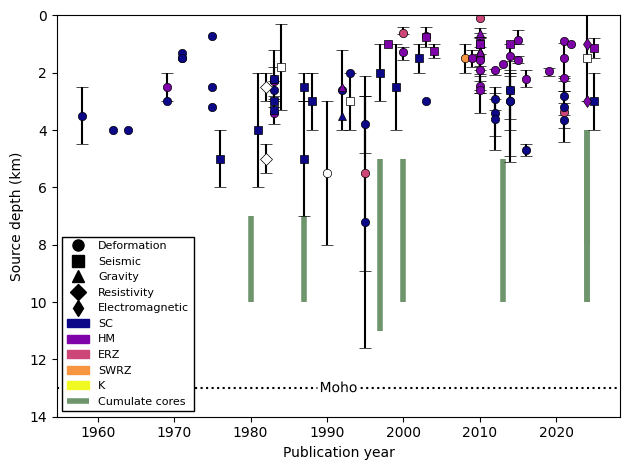

In [47]:
from labellines import labelLines

methods = ['Deformation', 'Seismic', 'Gravity', 'Resistivity', 'Electromagnetic']
markers = ['o', 's', '^', 'D', 'd','*'] 

color_by_col = 'Region (SC, HM, K, ERZ, SWRZ) '
chosen_cmap='plasma'
unique_vals = geophysics[color_by_col].dropna().astype(str).unique()
colors_map = {val: mpl.colormaps[chosen_cmap](s) for val, s in zip(unique_vals, np.linspace(0, 1, len(unique_vals)))}

plt.vlines(x=geophysics['Publication year'], 
           ymin=geophysics['Cumulate upper depth (km)'].astype('float64'), 
           ymax=geophysics['Cumulate lower depth (km)'].astype('float64'), 
          colors="#6F956D", linestyles='-', label='Cumulate cores',linewidths=4)

for method, marker in zip(methods, markers):
    mask = geophysics['Main Geophysical method (Deformation, Seismic, Gravity, Resistivity, Electromagnetic)'].str.contains(method, na=False)
    subset = geophysics[mask]

    for _, row in subset.iterrows():
        x = row['Publication year']
        y = float(row['Depth (km)'])
        yerr = [[float(row['Depth uncertainty left (-km)'])], [float(row['Depth uncertainty right (+km)'])]]

        color_key = str(row[color_by_col])
        chosen_color = colors_map.get(color_key, 'white')

        plt.errorbar(x, y, yerr=yerr, fmt=marker, color=chosen_color,
                     ecolor='black', capsize=4, mec='k',markeredgewidth=0.5)

moho_line = plt.axhline(y=13, color='black', linestyle=':', linewidth=1.5, label='Moho')
labelLines([moho_line], align=True, fontsize=10, color='black', zorder=10)

handles, labels = plt.gca().get_legend_handles_labels()

handles_filtered = [h for h, l in zip(handles, labels) if l != 'Moho']
labels_filtered = [l for l in labels if l != 'Moho']

method_handles = [
    mpl.lines.Line2D([], [], color='black', marker=m, linestyle='None', markersize=8, label=method)
    for method, m in zip(methods, markers)
]

region_handles = [
    mpl.patches.Patch(color=colors_map[val], label=val)
    for val in unique_vals
]

all_handles = method_handles + region_handles + handles_filtered
all_labels = (
    [h.get_label() for h in method_handles] +
    [h.get_label() for h in region_handles] +
    labels_filtered)

plt.xlabel('Publication year')
plt.ylabel('Source depth (km)')
plt.ylim([14,0])
plt.legend(
    all_handles,
    all_labels,
    loc='best',  fancybox=False, edgecolor='black',              
    ncol=1, fontsize=8,framealpha=1                        
)

plt.tight_layout()
plt.show()



,Reference Study,Publication year,Ref short,Activity,"Main Geophysical method (Deformation, Seismic, Gravity, Resistivity, Electromagnetic)",Study type,Deformation source geometry,Source #,"Region (SC, HM, K, ERZ, SWRZ)",Time Period (month/year or year),Reservoir locations,"Depth measured, inferred, external (M or I,E)","Reservoir depth is a range (R ), mean (A), best-fit (B), Best-fit MCMC (BMC)",Depth (km),Depth uncertainty left (-km),Depth uncertainty right (+km),Cumulate upper depth (km),Cumulate lower depth (km),Comments
74,Poland [2014],2014,P14,Inflation and deflation 2000-2009,Deformation,INSAR. GPS TILT AND REVIEW;Inversion of INSAR ...,Point source,2,K,2004-2005,SEHalema'uma'u near Keanakākoʻi,M,BMC,2.6,0.6,2.3,NaN,NaN,This one is east of the typical NE source of HM


### Import new Pre-Post Caldera data


In [4]:
newdata=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Notebook_Compiled_data'+slash+'FinalNewDataset.xlsx')

newdata =newdata.loc[:, ~newdata.columns.str.contains('Unnamed')].copy()
newdata = newdata.drop(columns='i')
newdata['Day']=newdata['Day'].astype(int)
newdata.insert(newdata.columns.get_loc('Atomic %_Ti_Ol')+1,'Total_Atomic%_Ol',newdata.loc[:, (newdata.columns.str.contains('Atomic'))&(newdata.columns.str.contains('Ol'))].sum(axis=1).where(lambda x: x != 0, np.nan))
newdata.insert(newdata.columns.get_loc('Total_Atomic%_Ol')+1,'(Mg+Fe)/Si_Atomic%_Ol',(newdata['Atomic %_Mg_Ol']+newdata['Atomic %_Mg_Ol'])/newdata['Atomic %_Si_Ol'].where(lambda x: x != 0, np.nan))
newdata.insert(newdata.columns.get_loc('σ Density g/cm3 (from densimeter)'),'σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)',np.nan)
# newdata.to_clipboard(excel=True)
newdata.head()


,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),"σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)",σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,919_50_FIA,0.141984,0.008781,0.007880,NaN,0.003876,103.108584,0.019886,0.000992,0.019891,...,1586.067191,50,0.141984,0.008781,NaN,0,denlinger_lerner,DZ06,0.065145,0.033490
1,919_50_FIB,0.151694,0.004892,0.002947,NaN,0.003905,103.133089,0.007437,0.000995,0.007381,...,1586.067191,50,0.151694,0.004892,NaN,0,denlinger_lerner,DZ06,0.061202,0.031835
2,919_51_FIA,0.191270,0.004434,0.003749,NaN,0.002369,103.221905,0.009185,0.001005,0.009143,...,1585.870579,50,0.191270,0.004434,NaN,0,denlinger_lerner,DZ06,0.051709,0.028335
3,919_52_FIA,0.153743,0.004916,0.002978,NaN,0.003912,103.138260,0.007515,0.001008,0.007458,...,1581.879866,50,0.153743,0.004916,NaN,0,denlinger_lerner,DZ06,0.060602,0.031591
4,919_52_FIB,0.143131,0.005096,0.003305,NaN,0.003879,103.111478,0.008341,0.001011,0.008292,...,1582.911649,50,0.143131,0.005096,NaN,0,denlinger_lerner,DZ06,0.064755,0.033323


### Import the re-processed JPET data (September 2023 rapid response)
We re-processed (SO2 mol%, T from Fo, XH2O and PD MC simulations) this literature dataset for consistency in comparisons

In [5]:
K23=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Notebook_Compiled_data'+slash+'K23_recalculated.xlsx')

## We need to drop some old columns and rename some others to merge correctly with the new data

K23 =K23.loc[:, ~K23.columns.str.contains('Unnamed|Old|P_kbar_1150C|SO2_mol%|py_index|Recalculations for Pre-Post Caldera paper >|T_C')]
K23 = K23.drop(columns='i')
K23['decrepit']=K23['decrepit'].astype(object)
K23['sulfide']=K23['sulfide'].astype(object)
K23.drop(columns=['Column headers', 'EDS Data >>', 'Depth (km)_ryanlerner',], inplace=True)
K23.rename(columns={'Corrected_Splitting (cm-1)':'Corrected_Splitting', 
                     'Splitting (cm-1)':'Splitting',
                    'Crystal Name':'Sample_crystal',
                    'EDS_Name':'Name_on_SEM',
                    'FI Name':'FI_name',
                    'O':'Atomic %_O_Ol','Mg':'Atomic %_Mg_Ol','Fe':'Atomic %_Fe_Ol','Si':'Atomic %_Si_Ol',
                    'Total':"Total_Atomic%_Ol",
                    '(Mg+Fe)/Si':'(Mg+Fe)/Si_Atomic%_Ol',
                    'Filename':'filename',
                    'Fo':'Fo_Ol',
                    'SO2 mol%_recalculated':'SO2 mol%',
                    'σ Density g/cm3 (DiadFit)':'σ Density g/cm3',
                    'Reported density mean of reps?':'averaged?',
                    'STDofreps_Density g/cm3':'Density g/cm3_Raman_STD',
                    'σ Density g/cm3 (as plotted, from DiadFit for individual, Std dev for averaged FI)':'σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)'}
                    , inplace=True)

K23.head()


,Sample_crystal,FI_name,averaged?,Density g/cm3,"σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)",Density g/cm3_Raman_STD,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),σ Density g/cm3 (from densimeter),Corrected_Splitting,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,K23_101,K23_101_FIC,No,0.085665,0.007736,NaN,0.007736,0.006738,0.003801,102.966450,...,1565.805593,50,0.085665,0.007736,NaN,0,denlinger_lerner,DZ06,0.108233,0.053578
1,K23_101,K23_101_FID,No,0.100137,0.005037,NaN,0.005037,0.003301,0.003805,103.002974,...,1565.805593,50,0.100137,0.005037,NaN,0,denlinger_lerner,DZ06,0.093852,0.046643
2,K23_102,K23_102_FIA,No,0.112454,0.004482,NaN,0.004482,0.002350,0.003817,103.034058,...,1564.096549,50,0.112454,0.004482,NaN,0,denlinger_lerner,DZ06,0.083756,0.041885
3,KS23_103,K23_103_FIC,No,0.114374,0.004013,NaN,0.004013,0.001231,0.003819,103.038904,...,1511.482018,50,0.114374,0.004013,NaN,0,denlinger_lerner,DZ06,0.085135,0.042535
4,KS23_103,K23_103_FID,Yes,0.126346,0.001619,0.001619,0.004087,0.001400,0.003839,103.069118,...,1511.482018,50,0.126346,0.001619,NaN,0,denlinger_lerner,DZ06,0.076872,0.038712


### Now merge K23 with all except LERZ2018

In [6]:
newdata_noK23=newdata.copy()
newdata=pd.merge(newdata,K23,how='outer')
newdata['SO2 mol%']=newdata['SO2 mol%'].fillna(0)

newdata


,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),"σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)",σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,NaN,0.004106,0.000000,0.000000,0.0,0.000000,102.760619,3.238335e-02,0.000252,3.245870e-02,...,1549.503246,50,0.004106,0.000000,NaN,0,denlinger_lerner,DZ06,0.263381,0.145350
1,KL0920_c216_a2_FID,0.006448,0.020385,0.019995,NaN,0.003967,102.766530,5.046291e-02,0.000777,5.056397e-02,...,1448.871909,50,0.006448,0.020385,NaN,0,denlinger_lerner,DZ06,0.257385,0.140755
2,K24_5_FIA,0.008291,0.005223,0.003406,NaN,0.003960,102.771180,8.595769e-03,0.000935,8.562497e-03,...,1542.887829,50,0.008291,0.005223,NaN,0,denlinger_lerner,DZ06,0.250687,0.135796
3,KL0921_c288_a1_FIA,0.009482,0.015142,0.014616,NaN,0.003955,102.774185,3.688741e-02,0.000666,3.696072e-02,...,1490.208717,50,0.009482,0.015142,NaN,0,denlinger_lerner,DZ06,0.248156,0.133970
4,K21-78b-FI#5,0.009713,0.009637,0.008789,NaN,0.003954,102.774769,2.218023e-02,0.000592,2.221888e-02,...,1552.879850,50,0.009713,0.009637,NaN,0,denlinger_lerner,DZ06,0.246373,0.132693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,919_65_A_rep1_12mW,0.418074,0.003000,0.001862,NaN,0.002349,103.754751,4.170363e-03,0.000747,4.111034e-03,...,1586.882879,50,0.418074,0.025375,NaN,0,denlinger_lerner,DZ06,0.000000,0.000000
590,KL0919-013-A,0.418887,0.004518,0.003807,NaN,0.002349,103.756680,8.516545e-03,0.000940,8.466252e-03,...,1584.076867,50,0.418887,0.014657,NaN,0,denlinger_lerner,DZ06,0.000000,0.000000
591,KL0910_c002_a1_FIH,0.443789,0.004923,0.004314,NaN,0.002350,103.812169,9.547276e-03,0.000495,9.554514e-03,...,1572.618293,50,0.443789,0.009674,NaN,0,denlinger_lerner,DZ06,0.000000,0.000000
592,KL0919-008-A,0.452379,0.002782,0.001487,NaN,0.002351,103.831189,3.279502e-03,0.001030,3.117947e-03,...,1579.837432,50,0.452379,0.002782,NaN,0,denlinger_lerner,DZ06,0.000000,0.000000


### Import the re-processed LERZ 2018 data (GPL paper)
We re-processed (SO2 mol%, T from Fo, XH2O and PD MC simulations) this literature dataset for consistency in comparisons

In [7]:
LERZ2018=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Notebook_Compiled_data'+slash+'LERZ2018_recalculated.xlsx')
LERZ2018 =LERZ2018.loc[:, ~LERZ2018.columns.str.contains('Unnamed')]
LERZ2018['Day']=LERZ2018['Day'].astype(int)
LERZ2018['Int_time (s)']=LERZ2018['Int_time (s)'].astype(float)
LERZ2018['Sample_crystal']=LERZ2018['Host crystal ID']
LERZ2018['SO2 mol%']=LERZ2018['SO2 mol%_recalculated'].fillna(0)

LERZ2018.head()

,Py_index,Event Description,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Host crystal ID,Fluid inclusion ID,Raman Data >,Fermi Diad separation ΔCO2 (cm-1),Corrected ΔCO2 (cm-1),Corrected ΔCO2 1σ (cm-1),CO2 density (g/cm3),...,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O,Sample_crystal,SO2 mol%
0,0,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#1,ν1 refers to the low wavenumber band of the fe...,103.416763,103.186144,0.006461,0.176605,...,0.176605,0.001314,NaN,0,denlinger_lerner,DZ06,0.055466,0.029614,LL4-14dp,4.088172
1,1,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#2,NaN,103.431244,103.195894,0.007137,0.180578,...,0.180578,0.002910,NaN,0,denlinger_lerner,DZ06,0.054643,0.029323,LL4-14dp,2.406601
2,2,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-MI#1,NaN,103.429713,103.196578,0.010404,0.180858,...,0.180858,0.004029,NaN,0,denlinger_lerner,DZ06,0.054514,0.029278,LL4-14dp,6.492751
3,3,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-#2,NaN,103.379425,103.122405,0.001766,0.147317,...,0.147317,0.001696,NaN,0,denlinger_lerner,DZ06,0.066753,0.034190,LL4-21,0.000000
4,7,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-MI#5,NaN,103.170121,102.953345,0.007431,0.080378,...,0.080378,0.002942,NaN,0,denlinger_lerner,DZ06,0.116065,0.057431,LL4-21,0.000000


##### I don't think I can merge LERZ, it's too different, I'd have to rename 220 columns/285

In [8]:
only_in_LERZ2018 = set(LERZ2018.columns) - set(newdata.columns)
len(only_in_LERZ2018)

220

#### If someone else wants this data, this extracts the essentials for plotting

In [9]:
# sub_newdata=newdata[['Sample','FI_name',
#                   'SingleCalc_D_km', 'std_dev_MC_D_km',
#                  'SingleCalc_P_kbar', 'std_dev_MC_P_kbar',
#                 ]]

# sub_LERZ=LERZ2018[['Eruption', 'Fluid inclusion ID',
#                   'SingleCalc_D_km', 'std_dev_MC_D_km',
#                  'SingleCalc_P_kbar', 'std_dev_MC_P_kbar',
#                 ]]

# sub_LERZ=sub_LERZ.rename(columns={'Fluid inclusion ID':'FI_name','Eruption':'Sample'})


# Kil_4_Matt=pd.concat([sub_newdata,sub_LERZ],axis=0)

# Kil_4_Matt.to_clipboard(excel=True)

In [10]:
newdata[newdata['Sample'].str.contains('KL09')]['Sample'].unique()


array(['KL0920', 'KL0921', 'KL0910', 'KL0914', 'KL0908', 'KL0917',
       'KL0916', 'KL0931', 'KL0924', 'KL0909', 'KL0930', 'KL0919'],
      dtype=object)

## 4. Plot Depth violins

### This filters by SO2 according to a specific cutoff

In [11]:
SO2_cutoff=None

newdata=newdata[~(newdata['SO2 mol%']>SO2_cutoff)]
# plottingdata=newdata[~(newdata['SO2 mol%']>SO2_cutoff)].copy()

LERZ2018=LERZ2018[~(LERZ2018['SO2 mol%']>SO2_cutoff)]

# This just creates sample filters for plotting
UW=newdata[(newdata['Sample'].str.contains('UW'))]
K21=newdata[(newdata['Sample'].str.contains('K21|921'))]
L84=newdata[(newdata['Sample'].str.contains('L84'))]
Ulu_919=newdata[newdata['Sample'].str.contains('919|920')]
K20=newdata[(newdata['Sample'].str.contains('K20'))]
K24=newdata[(newdata['Sample'].str.contains('K24'))]
KD24=newdata[(newdata['Sample'].str.contains('KD24'))]
Ulu_910=newdata[newdata['Sample'].str.contains('910')]
Ulu_908=newdata[newdata['Sample'].str.contains('908')]
Ulu_909=newdata[newdata['Sample'].str.contains('909')]
Ulu_916=newdata[newdata['Sample'].str.contains('916')]
Ulu_931=newdata[newdata['Sample'].str.contains('931')]
Ulu_914=newdata[newdata['Sample'].str.contains('914')]
Ulu_916=newdata[newdata['Sample'].str.contains('916')]
Ulu_917=newdata[newdata['Sample'].str.contains('917')]
Ulu_924=newdata[newdata['Sample'].str.contains('924')]
Iki_930=newdata[newdata['Sample'].str.contains('930')]
K23=newdata[newdata['Sample'].str.contains('K23')]


### Now plot

### All FI, all eruptions

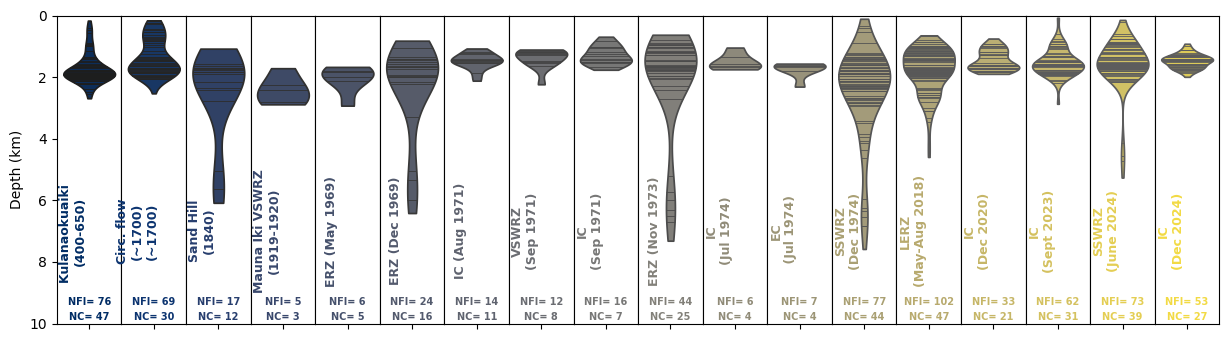

In [12]:
# Define datasets
datasets = [UW,K21,L84,
            Iki_930,
            Ulu_909,
            Ulu_908,
            Ulu_916,
            Ulu_931,
            Ulu_914,
            Ulu_910,
            Ulu_917,
            Ulu_924,
            Ulu_919,  
            LERZ2018, K20, K23, K24, KD24]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "ERZ (May 1969)",
          "ERZ (Dec 1969)",
          "IC (Aug 1971)",
          "VSWRZ\n(Sep 1971)",
          "IC\n(Sep 1971)",
          "ERZ (Nov 1973)",
          "IC\n(Jul 1974)",
          "EC\n (Jul 1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", "IC\n(Dec 2020)", "IC\n(Sept 2023)", "SSWRZ\n(June 2024)", "IC\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(15, 4), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['SingleCalc_D_km'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([10, 0])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.3), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')
    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=fontsize-2,
            ha='center', va='center', color=ann_color, fontweight='bold')
# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Kil_violin_plot_alleruptions.pdf', format='pdf', dpi=300, transparent=False)


### PLotting maximum pressure per crystal only, eruptions grouped

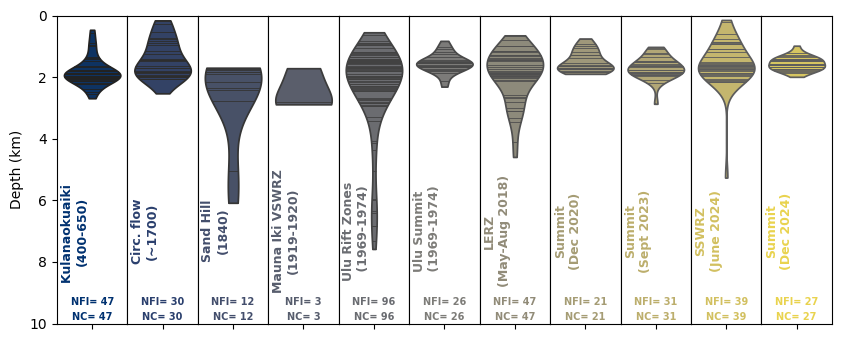

In [58]:
max_pressures_only = newdata.loc[newdata.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]

Ulu_all=max_pressures_only[max_pressures_only['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(max_pressures_only['SO2 mol%']>SO2_cutoff)]
Ulu_summit=max_pressures_only[max_pressures_only['Sample'].str.contains('914|916|917|924')&~(max_pressures_only['SO2 mol%']>SO2_cutoff)]
Ulu_rzs=max_pressures_only[max_pressures_only['Sample'].str.contains('908|909|910|931|919')&~(max_pressures_only['SO2 mol%']>SO2_cutoff)]
UW_plot=UW.loc[UW.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
K21_plot=K21.loc[K21.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
L84_plot=L84.loc[L84.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
Iki_930_plot=Iki_930.loc[Iki_930.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
LERZ2018_plot=LERZ2018.loc[LERZ2018.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
K20_plot=K20.loc[K20.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
K23_plot=K23.loc[K23.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
K24_plot=K24.loc[K24.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
KD24_plot=KD24.loc[KD24.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]

# Define datasets
datasets = [UW_plot,K21_plot,L84_plot,
            Iki_930_plot,
            Ulu_rzs,
            Ulu_summit,
            LERZ2018_plot, K20_plot, K23_plot, K24_plot, KD24_plot]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", "Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)", "Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(10, 4), sharey=True)



# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):

    # Create violin plot
    sns.violinplot(data=data['SingleCalc_D_km'], color=ann_color, inner='stick', ax=ax, cut=0,bw_method='silverman')
    
    # Set y-axis properties
    ax.set_ylim([10, 0])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.3), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')
    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=fontsize-2,
            ha='center', va='center', color=ann_color, fontweight='bold')
# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Kil_violin_plot_maxP_only.pdf', format='pdf', dpi=300, transparent=False)


### All FI, eruptions grouped.

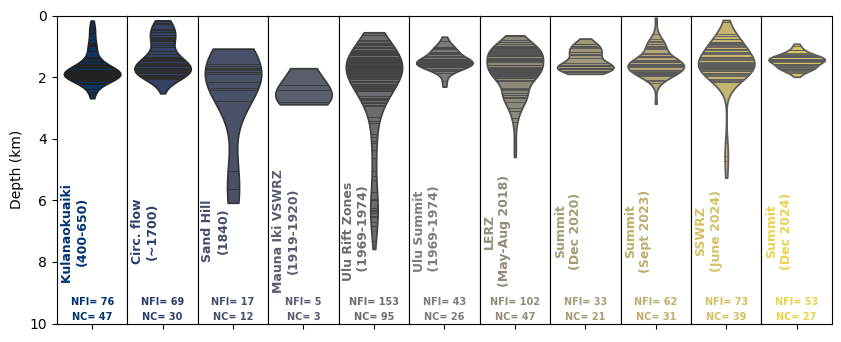

In [59]:
newdata['FI_type']=newdata['FI_type'].astype(str)
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

# Define datasets
datasets = [UW,K21,L84,
            Iki_930,
            Ulu_rzs,
            Ulu_summit,
            LERZ2018, K20, K23, K24, KD24]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", "Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)", "Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(10, 4), sharey=True)



# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):

    # Create violin plot
    sns.violinplot(data=data['SingleCalc_D_km'], color=ann_color, inner='stick', ax=ax, cut=0,bw_method='silverman')
    
    # Set y-axis properties
    ax.set_ylim([10, 0])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.3), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')
    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=fontsize-2,
            ha='center', va='center', color=ann_color, fontweight='bold')
# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Kil_violin_plot_allFI_grouped.pdf', format='pdf', dpi=300, transparent=False)


## plot fo vs depths

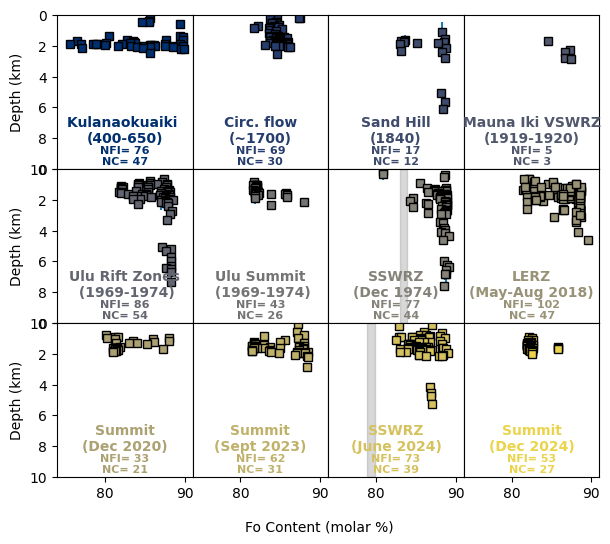

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

# Define datasets
datasets = [UW,K21,L84,
            Iki_930,
            Ulu_rzs,
            Ulu_summit,
            Ulu_919,
            LERZ2018, K20, K23, K24, KD24]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", "Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)", "Summit\n(Dec 2024)"]


num_axes = len(datasets)
num_cols = math.ceil(num_axes / 3)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(3, num_cols, figsize=(7,6), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='k', mfc=ann_color, fmt='s')

    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([74, 91])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color=ann_color, fontweight='bold')

    if title =="SSWRZ\n(Dec 1974)":
        ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    elif title =="SSWRZ\n(June 2024)":
        ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0.02, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'Kil_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()



## SO2 vs P

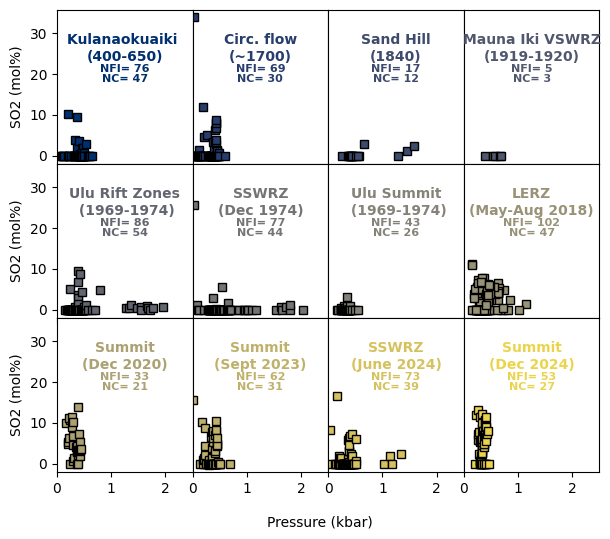

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

# Define datasets
datasets = [UW,K21,L84,
            Iki_930,
            Ulu_rzs,
            Ulu_919,
            Ulu_summit,
            LERZ2018, K20, K23, K24, KD24]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", "Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)", "Summit\n(Dec 2024)"]

annotation_colors = sns.color_palette("cividis", len(datasets))

fig, axes = plt.subplots(3, num_cols, figsize=(7,6), sharey=True, sharex=True)
axes = axes.flatten()

for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    x = data['SingleCalc_P_kbar']

    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SO2 mol%'], 
                    mec='k', mfc=ann_color, fmt='s')

    # Set axis limits
    # ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([0, 2.5])  

    if i % num_cols == 0:
        ax.set_ylabel('SO2 (mol%)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.75), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.62), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.55), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color=ann_color, fontweight='bold')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0.02, 'Pressure (kbar)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'Kil_SO2P_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()



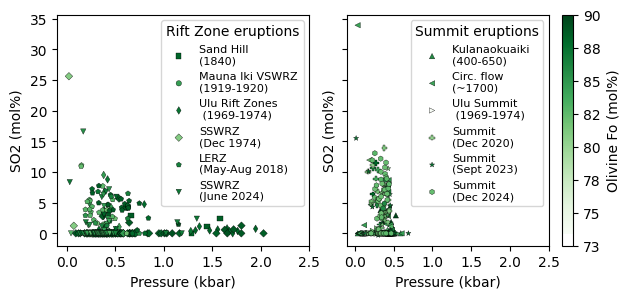

In [62]:
datasets = [L84, Iki_930, Ulu_rzs, Ulu_919,LERZ2018,K24,  
           UW, K21, Ulu_summit, K20, K23, KD24]
titles = ["Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", 
          "SSWRZ\n(June 2024)",
          "Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)",
          "Ulu Summit\n (1969-1974)","Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "Summit\n(Dec 2024)" ]

all_fo_ol = []
for data, title in zip(datasets, titles):
    if 'LERZ' in title:
        all_fo_ol.extend(data['Corrected Fo content (molar %)_Cambridge'].values)
    elif 'Sept 2023' in title:
        all_fo_ol.extend(data['Fo_Ol'].values)
    else:
        all_fo_ol.extend(data['Fo_Ol'].values)

all_fo_ol = np.array(all_fo_ol)
all_fo_ol = np.where(all_fo_ol > 1, all_fo_ol / 100, all_fo_ol)

global_min = np.nanmin(all_fo_ol)
global_max = np.nanmax(all_fo_ol)

markers = ['s', 'o', 'd', 'D', 'p', 'v', '^', '<', '>', 'P', '*', 'h']
fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True, sharex=True)
plt.subplots_adjust(hspace=0, wspace=0.15)

for i, (data, title, marker) in enumerate(zip(datasets, titles, markers)):

    if 'LERZ' in title:
        fo_ol = data['Corrected Fo content (molar %)_Cambridge']
    elif 'Sept 2023' in title:
        fo_ol = data['Fo_Ol']
    else:
        fo_ol = data['Fo_Ol']

    if np.any(fo_ol>1):
        fo_ol=fo_ol/100

    norm = plt.Normalize(vmin=global_min, vmax=global_max)
    colors= np.array(plt.cm.Greens(norm(fo_ol)))

    nan_mask = np.isnan(fo_ol)
    colors[nan_mask] = [1.0, 1.0, 1.0, 1.0]


    if i<6:
        axes[0].scatter(data['SingleCalc_P_kbar'], data['SO2 mol%'], 
                        c=fo_ol, cmap='Greens', norm=norm, marker=marker, label=title,alpha=1,edgecolors='k',linewidths=0.25,s=15)
    else:
        axes[1].scatter(data['SingleCalc_P_kbar'], data['SO2 mol%'], 
                        c=fo_ol,cmap='Greens',norm=norm, marker=marker, label=title,alpha=1,edgecolors='k',linewidths=0.25,s=15)

for ax in axes:

    ax.set_xlim([-0.1, 2.5])
    ax.set_ylabel('SO2 (mol%)')
    ax.set_xlabel('Pressure (kbar)')

axes[0].legend(fontsize=8,title='Rift Zone eruptions')
axes[1].legend(fontsize=8,title='Summit eruptions')

sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Olivine Fo (mol%)')

tick_locs = cbar.get_ticks()
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([f"{t * 100:.0f}" for t in tick_locs])

plt.show()


### Plot FI size vs Pressure


In [63]:
# Calculate scaled semiaxes for FI 
def scale(row, column_name):
    if row['mag'] == 50:
        return (row[column_name]) * 223.161 / 1920
    elif row['mag'] == 20:
        return (row[column_name]) * 546.419 / 1920
    elif row['mag'] == 100:
        return (row[column_name]) * 109.989 / 1920
    else:
        return None

newdata['FI_semiaxis_a_um_scaled'] = newdata.apply(scale, axis=1, column_name='FI_axis_a_um')
newdata['FI_semiaxis_b_um_scaled'] = newdata.apply(scale, axis=1, column_name='FI_axis_b_um')

LERZ2018['FI_semiaxis_a_um_scaled'] =LERZ2018.apply(scale, axis=1, column_name='FI_axis_a_um')
LERZ2018['FI_semiaxis_b_um_scaled'] =LERZ2018.apply(scale, axis=1, column_name='FI_axis_b_um')

newdata['FI_Area_um_scaled']=np.pi*newdata['FI_semiaxis_a_um_scaled']*newdata['FI_semiaxis_b_um_scaled']


Text(0, 0.5, 'P_kbar')

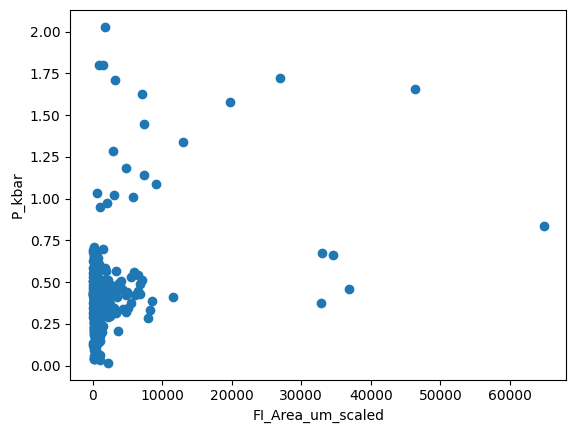

In [64]:
plt.scatter(newdata['FI_Area_um_scaled'],newdata['SingleCalc_P_kbar'])
plt.xlabel("FI_Area_um_scaled")
plt.ylabel("P_kbar")

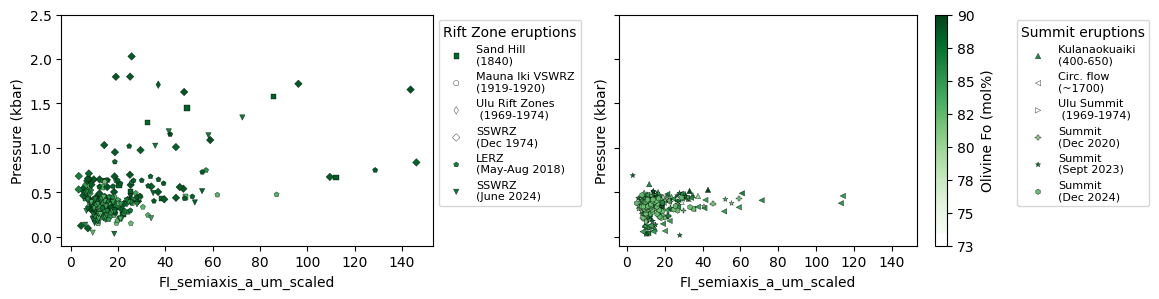

In [65]:
# This just creates sample filters for plotting
UW=newdata[(newdata['Sample'].str.contains('UW'))]
K21=newdata[(newdata['Sample'].str.contains('K21|921'))]
L84=newdata[(newdata['Sample'].str.contains('L84'))]
Ulu_919=newdata[newdata['Sample'].str.contains('919|920')]
K20=newdata[(newdata['Sample'].str.contains('K20'))]
K24=newdata[(newdata['Sample'].str.contains('K24'))]
KD24=newdata[(newdata['Sample'].str.contains('KD24'))]
Ulu_910=newdata[newdata['Sample'].str.contains('910')]
Ulu_908=newdata[newdata['Sample'].str.contains('908')]
Ulu_909=newdata[newdata['Sample'].str.contains('909')]
Ulu_916=newdata[newdata['Sample'].str.contains('916')]
Ulu_931=newdata[newdata['Sample'].str.contains('931')]
Ulu_914=newdata[newdata['Sample'].str.contains('914')]
Ulu_916=newdata[newdata['Sample'].str.contains('916')]
Ulu_917=newdata[newdata['Sample'].str.contains('917')]
Ulu_924=newdata[newdata['Sample'].str.contains('924')]
Iki_930=newdata[newdata['Sample'].str.contains('930')]
K23=newdata[newdata['Sample'].str.contains('K23')]

Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]


datasets = [L84, Iki_930, Ulu_rzs, Ulu_919,LERZ2018,K24,  
           UW, K21, Ulu_summit, K20, K23, KD24]
titles = ["Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", 
          "SSWRZ\n(June 2024)",
          "Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)",
          "Ulu Summit\n (1969-1974)","Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "Summit\n(Dec 2024)" ]

all_fo_ol = []
for data, title in zip(datasets, titles):
    if 'LERZ' in title:
        all_fo_ol.extend(data['Corrected Fo content (molar %)_Cambridge'].values)
    elif 'Sept 2023' in title:
        all_fo_ol.extend(data['Fo_Ol'].values)
    else:
        all_fo_ol.extend(data['Fo_Ol'].values)

all_fo_ol = np.array(all_fo_ol)
all_fo_ol = np.where(all_fo_ol > 1, all_fo_ol / 100, all_fo_ol)

global_min = np.nanmin(all_fo_ol)
global_max = np.nanmax(all_fo_ol)

markers = ['s', 'o', 'd', 'D', 'p', 'v', '^', '<', '>', 'P', '*', 'h']

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True, sharex=True)
plt.subplots_adjust(hspace=0, wspace=0.5)

for i, (data, title, marker) in enumerate(zip(datasets, titles, markers)):

    if 'LERZ' in title:
        fo_ol = data['Corrected Fo content (molar %)_Cambridge']
    elif 'Sept 2023' in title:
        fo_ol = data['Fo_Ol']
    else:
        fo_ol = data['Fo_Ol']

    if np.any(fo_ol>1):
        fo_ol=fo_ol/100

    norm = plt.Normalize(vmin=global_min, vmax=global_max)
    colors= np.array(plt.cm.Greens(norm(fo_ol)))

    nan_mask = np.isnan(fo_ol)
    colors[nan_mask] = [1.0, 1.0, 1.0, 1.0]


    if i<6:
        axes[0].scatter(y=data['SingleCalc_P_kbar'], x=data['FI_semiaxis_a_um_scaled'], 
                        c=fo_ol, cmap='Greens', norm=norm, marker=marker, label=title,alpha=1,edgecolors='k',linewidths=0.25,s=15)
    else:
        axes[1].scatter(y=data['SingleCalc_P_kbar'], x=data['FI_semiaxis_a_um_scaled'], 
                        c=fo_ol,cmap='Greens',norm=norm, marker=marker, label=title,alpha=1,edgecolors='k',linewidths=0.25,s=15)

for ax in axes:

    ax.set_ylim([-0.1, 2.5])
    ax.set_xlabel('FI_semiaxis_a_um_scaled')
    ax.set_ylabel('Pressure (kbar)')

axes[0].legend(fontsize=8,title='Rift Zone eruptions', bbox_to_anchor=(1, 1))
axes[1].legend(fontsize=8,title='Summit eruptions', bbox_to_anchor=(1.8, 1))

sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Olivine Fo (mol%)')

tick_locs = cbar.get_ticks()
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([f"{t * 100:.0f}" for t in tick_locs])

plt.show()


## Plot EBSD data

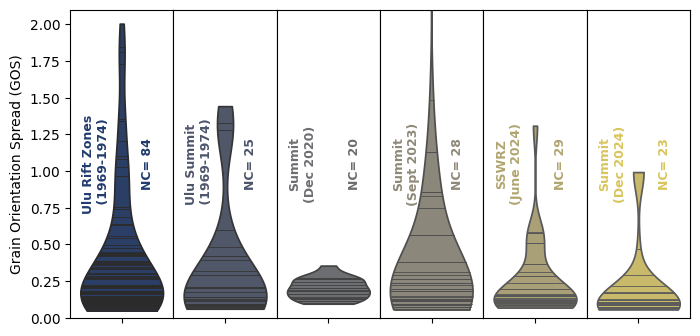

In [66]:
# Define datasets
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919|920')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

datasets = [ Ulu_rzs,Ulu_summit,K20,K23, K24, KD24]
titles = ["Ulu Rift Zones\n (1969-1974)",
             "Ulu Summit\n (1969-1974)",
            "Summit\n(Dec 2020)",  "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(8, 4), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([0,2.1])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Grain Orientation Spread (GOS)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {data[(data['GOS'].notna()) & (data['Sample_crystal'].notna())]['Sample_crystal'].nunique()}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'GOS_violin_plot.pdf', format='pdf', dpi=300, transparent=False)


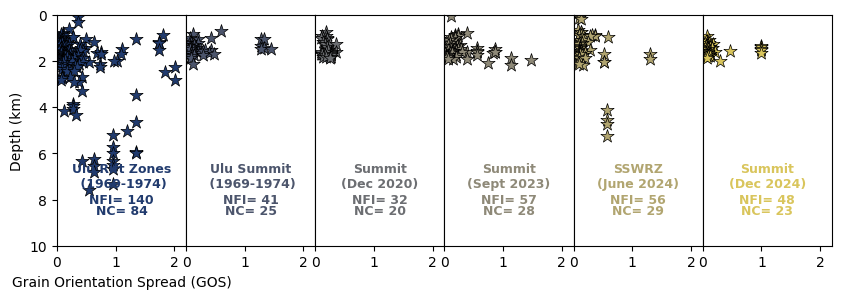

In [67]:
# Define datasets
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919|920')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

datasets = [ Ulu_rzs,Ulu_summit,K20,K23, K24, KD24]
titles = ["Ulu Rift Zones\n (1969-1974)",
             "Ulu Summit\n (1969-1974)",
            "Summit\n(Dec 2020)",  "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(10, 3), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    ax.scatter(x=data['GOS'],y=data['SingleCalc_D_km'],marker='*',s=100,linewidths=0.5,edgecolors='k',color=ann_color)
    # sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([10,0])  # Inverted y-axis
    ax.set_xlim([0,2.2])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Depth (km)')
        ax.set_xlabel('Grain Orientation Spread (GOS)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.5, 0.30), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=0)
    ax.annotate(f"NFI= {len(data[(data['GOS'].notna())])}", xy=(0.5, 0.20), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=0)
    ax.annotate(f"NC= {data[(data['GOS'].notna()) & (data['Sample_crystal'].notna())]['Sample_crystal'].nunique()}", xy=(0.5, 0.15), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=0)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Pressure vs GOS_plot.pdf', format='pdf', dpi=300, transparent=False)

## Color by Fo content

## FO vs depth Ulu, EBSD as yellow dot

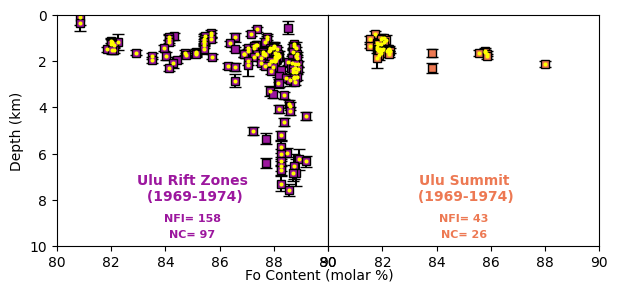

In [68]:
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919|920')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))] # This rz contains SSWRZ 1974

# Define datasets
datasets = [Ulu_rzs,
            Ulu_summit]
titles = ["Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)"]

num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    # Plot only if x has valid values
    
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='k', mfc=ann_color, fmt='s',capsize=4,ecolor='k',zorder=-1)
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
                   marker='.', color='yellow', label=None, s=15, linewidths=1,zorder=0)
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color=ann_color, fontweight='bold')

    if title =="SSWRZ\n(Dec 1974)":
        ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    elif title =="SSWRZ\n(June 2024)":
        ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'Ulu_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

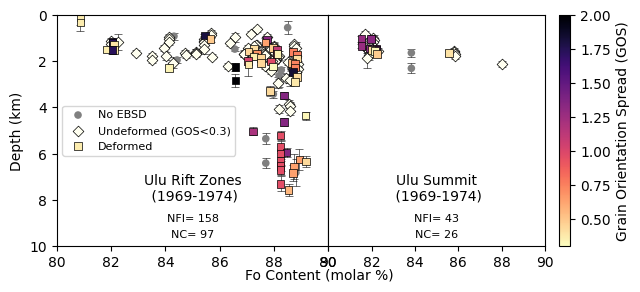

In [69]:
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919|920')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))] # This rz contains SSWRZ 1974

# Define datasets
datasets = [Ulu_rzs,
            Ulu_summit]
titles = ["Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)"]

num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.3
global_max = np.nanmax(Ulu_all[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)
        
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff=data['GOS']>=0.3
        # ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
        #            marker='s', color=ann_color, label=None, s=15, linewidths=1,zorder=0)
        ax.scatter(x[~gos_mask], data.loc[~gos_mask, 'SingleCalc_D_km'],
                    color='grey', marker='o', label='No EBSD',alpha=1,edgecolors='none',linewidths=0.3,s=30)
        ax.scatter(x[gos_mask&~gos_cutoff], data.loc[gos_mask&~gos_cutoff, 'SingleCalc_D_km'],
                    color='ivory', marker='D', label='Undeformed (GOS<0.3)',alpha=1,edgecolors='k',linewidths=0.5,s=30)
        ax.scatter(x[gos_mask&gos_cutoff], data.loc[gos_mask&gos_cutoff, 'SingleCalc_D_km'],
                    c=data[colorvar][gos_mask&gos_cutoff], cmap=palette, norm=norm, marker='s', label='Deformed',alpha=1,edgecolors='k',linewidths=0.5,s=30)

   
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color='k')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color='k')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color='k')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'Ulu_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

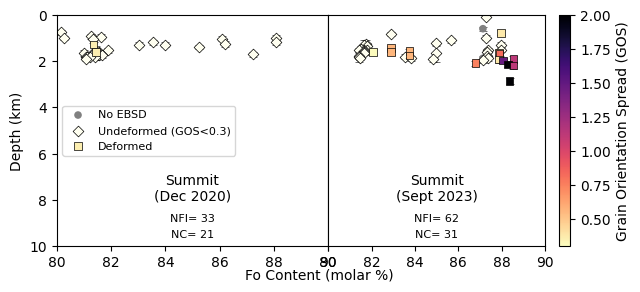

In [70]:
# Define datasets
datasets = [K20,K23]#,K24,KD24]
titles = ["Summit\n(Dec 2020)",  "Summit\n(Sept 2023)"]#, "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]
            # "Summit\n(Dec 2020)",  "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]
num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.3
global_max = np.nanmax(Ulu_all[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)
        
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff=data['GOS']>=0.3
        # ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
        #            marker='s', color=ann_color, label=None, s=15, linewidths=1,zorder=0)
        ax.scatter(x[~gos_mask], data.loc[~gos_mask, 'SingleCalc_D_km'],
                    color='grey', marker='o', label='No EBSD',alpha=1,edgecolors='none',linewidths=0.3,s=30)
        ax.scatter(x[gos_mask&~gos_cutoff], data.loc[gos_mask&~gos_cutoff, 'SingleCalc_D_km'],
                    color='ivory', marker='D', label='Undeformed (GOS<0.3)',alpha=1,edgecolors='k',linewidths=0.5,s=30)
        ax.scatter(x[gos_mask&gos_cutoff], data.loc[gos_mask&gos_cutoff, 'SingleCalc_D_km'],
                    c=data[colorvar][gos_mask&gos_cutoff], cmap=palette, norm=norm, marker='s', label='Deformed',alpha=1,edgecolors='k',linewidths=0.5,s=30)

   
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color='k')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color='k')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color='k')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'K20_K23_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

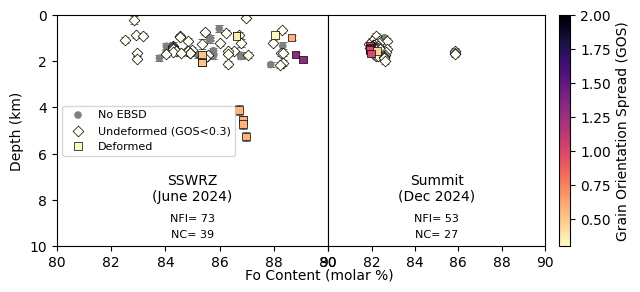

In [71]:
# Define datasets
datasets = [K24,KD24]
titles = ["SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]
            # "Summit\n(Dec 2020)",  "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]
num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.3
global_max = np.nanmax(Ulu_all[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)
        
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff=data['GOS']>=0.3
        # ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
        #            marker='s', color=ann_color, label=None, s=15, linewidths=1,zorder=0)
        ax.scatter(x[~gos_mask], data.loc[~gos_mask, 'SingleCalc_D_km'],
                    color='grey', marker='o', label='No EBSD',alpha=1,edgecolors='none',linewidths=0.3,s=30)
        ax.scatter(x[gos_mask&~gos_cutoff], data.loc[gos_mask&~gos_cutoff, 'SingleCalc_D_km'],
                    color='ivory', marker='D', label='Undeformed (GOS<0.3)',alpha=1,edgecolors='k',linewidths=0.5,s=30)
        ax.scatter(x[gos_mask&gos_cutoff], data.loc[gos_mask&gos_cutoff, 'SingleCalc_D_km'],
                    c=data[colorvar][gos_mask&gos_cutoff], cmap=palette, norm=norm, marker='s', label='Deformed',alpha=1,edgecolors='k',linewidths=0.5,s=30)

   
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color='k')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color='k')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color='k')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'K24_KD24_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

# Let'plot all of the EBSD regardless whether it has FI or not

In [ ]:

K20_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_KS20-527/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
KD24_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_KS24-628/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
Ulu_mounts_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_Ulu_mounts/EBSD/Combined_EBSD/Ulu_EBSD_combined_all.xlsx')

SWRZ_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_SWRZ/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
K24_EBSD_all=SWRZ_EBSD_all[SWRZ_EBSD_all['EBSD_name'].str.contains('K24')]
KL0919_EBSD_all=SWRZ_EBSD_all[SWRZ_EBSD_all['EBSD_name'].str.contains('919')]
Ulu_EBSD_all=pd.concat([Ulu_mounts_EBSD_all,KL0919_EBSD_all])

EBSD_data1=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'K23_EBSDmap'+slash+'K23_wholemount_052225 (montaged map)_grain_results.xlsx')
EBSD_data2=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'K23_EBSDmap'+slash+"K23_manual_map_day"+slash+'K23_1_grain_results.xlsx')
K23_EBSD_all=pd.concat([EBSD_data1,EBSD_data2])



,Unnamed: 0,Filename,Deformed,Slip_system,Blue_direction,Red_direction,Notes,Day,grainID,GOS,...,len20,file_mod,mean_length,median_length,Perc Tilt,Perc Twist,Perc unclassified,EBSD_name,EBSDname+grainID,Divangle
0,0.0,\Expl_600,Y,Y,SE,NE,0,100,80,1.413278,...,0.0,\Expl_600,195.100778,157.160961,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,\Expl_601,N,0,0,0,0,100,20,0.126191,...,0.0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,\Expl_601,N,0,0,0,0,100,2,0.180567,...,0.0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,\Expl_601,Y,Y,E,0,0,100,62,0.798379,...,0.0,\Expl_601,158.124051,130.973873,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,\Expl_602,M,0,0,0,0,100,33,0.355086,...,0.0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,NaN,\Rapid_response_day2 Specimen 1 919_67_5,Y,NaN,NaN,NaN,NaN,2,15,0.593880,...,NaN,NaN,NaN,NaN,99.487346,0.000000,5.126542e-01,919_67_5,919_67_5_15,1.0
183,NaN,\Rapid_response_day2 Specimen 1 919_67_5,Y,NaN,NaN,NaN,NaN,2,53,0.504836,...,NaN,NaN,NaN,NaN,67.408576,17.483124,1.510830e+01,919_67_5,919_67_5_53,1.0
184,NaN,\Rapid_response_day2 Specimen 1 919_67_5,Uncertain,NaN,NaN,NaN,NaN,2,57,0.092402,...,NaN,NaN,NaN,NaN,100.000000,0.000000,0.000000e+00,919_67_5,919_67_5_57,1.0
185,NaN,\Rapid_response_day2 Specimen 1 919_68_6,Uncertain,NaN,NaN,NaN,NaN,2,17,0.142322,...,NaN,NaN,NaN,NaN,65.649225,34.350775,4.141305e-15,919_68_6,919_68_6_17,2.0


In [ ]:
titles = ["Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", 
          "SSWRZ\n(June 2024)",
          "Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)",
          "Ulu Summit\n (1969-1974)","Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "Summit\n(Dec 2024)" ]


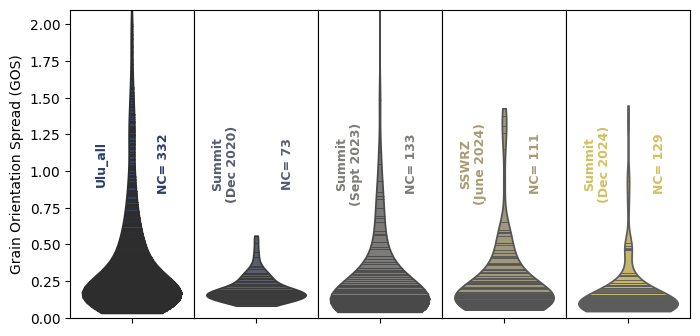

In [83]:
# Define datasets

datasets = [Ulu_EBSD_all,K20_EBSD_all,K23_EBSD_all,K24_EBSD_all,KD24_EBSD_all]
titles = ["Ulu_all","Summit\n(Dec 2020)","Summit\n(Sept 2023)","SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(8, 4), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([0,2.1])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Grain Orientation Spread (GOS)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {data[(data['GOS'].notna()) & (data['grainID'].notna())]['grainID'].nunique()}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'GOS_violin_plot_K20_allEBSD.pdf', format='pdf', dpi=300, transparent=False)


In [ ]:
K23

## Import Kendra unpubd olivines

In [97]:
KD24_ols_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"December2024HMM_Diffusion_Master_01142025.xlsx",sheet_name="CoreRim Master")

KD24_ols_Kendra =KD24_ols_Kendra.loc[:, ~KD24_ols_Kendra.columns.str.contains('Unnamed')].drop(KD24_ols_Kendra.tail(6).index)

KD24_ols_Kendra

,SAMPLE,SiO2 WT%,MgO WT%,FeO WT%,NiO WT%,CaO WT%,Total,Fo
0,KS24-617-WORI-1_ol1 Ave,39.484433,42.966033,16.818300,0.220630,0.252090,99.741487,81.994967
1,KS24-617-WORI-1_ol2 Ave,39.434500,43.270000,16.375867,0.230100,0.260377,99.570844,82.487267
2,KS24-617-WORI-1_ol3 Ave,39.454500,43.056700,16.785067,0.213760,0.263652,99.773679,82.055200
3,KS24-617-WORI-1_ol4 Ave,39.609700,43.774300,16.067400,0.240889,0.259273,99.951562,82.924867
4,KS24-617-WORI-1_ol5 Ave,39.827767,43.399333,16.089133,0.238321,0.259320,99.813874,82.783567
5,KS24-617-WORI-1_ol6 Ave,40.019867,43.167267,16.528433,0.209049,0.257977,100.182593,82.318333
6,KS24-617-WORI-1_ol7 Ave,39.756800,43.206733,16.186600,0.240085,0.262180,99.652399,82.633567
7,KS24-617-WORI-1_ol8 Ave,39.803033,42.790733,16.536900,0.236558,0.264095,99.631320,82.182900
8,KS24-617-WORI-1_ol9 Ave,39.686100,43.112600,16.428300,0.238447,0.256796,99.722243,82.388200
9,KS24-617-WORI-1_ol10 Ave,39.918667,43.145633,16.432300,0.224824,0.279385,100.000808,82.395733


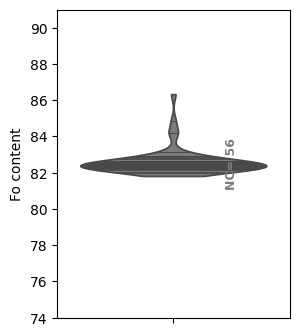

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define datasets
datasets = [KD24_ols_Kendra]  # Can have more datasets, but for now let's assume one
titles = ["SWRZ\n(Dec 1974)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(3, 4), sharey=True)

# If there's only one axis, make it iterable (like a list)
if num_axes == 1:
    axes = [axes]

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['Fo'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([0, 2.1])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Fo content')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    # ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
    #             ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {len(data[(data['Fo'].notna())])}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots

# Optionally set xlim
ax.set_ylim([74, 91])
fig.savefig(figpath + slash + 'Dec24_Kendra_Ol_violin_plot.pdf', format='pdf', dpi=300, transparent=False)


In [99]:
KD24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"December2024HMM_Diffusion_Master_01142025.xlsx",sheet_name="ol33")

KD24_ols_profiles_Kendra =KD24_ols_profiles_Kendra.loc[:, ~KD24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(KD24_ols_profiles_Kendra.tail(6).index)

KD24_ols_profiles_Kendra

,SAMPLE,SiO2 WT%,MgO WT%,FeO WT%,NiO WT%,CaO WT%,Total,Fo,RELDIST
0,Un 39 KS24-617-WORI-1_ol33_trav1,40.4104,43.8189,16.3836,0.219932,0.288659,101.121491,82.6618,0.00000
1,Un 39 KS24-617-WORI-1_ol33_trav1,40.3005,43.5617,16.3846,0.216461,0.275291,100.738552,82.5764,9.96572
2,Un 39 KS24-617-WORI-1_ol33_trav1,40.3067,43.7030,16.3504,0.225529,0.271164,100.856793,82.6530,20.00900
3,Un 39 KS24-617-WORI-1_ol33_trav1,40.1169,43.6395,16.2488,0.233582,0.268351,100.507133,82.7213,29.97470
4,Un 39 KS24-617-WORI-1_ol33_trav1,40.0354,43.6762,16.3202,0.231534,0.264374,100.527708,82.6706,40.01800
...,...,...,...,...,...,...,...,...,...
69,Un 40 KS24-617-WORI-1_ol33_trav2,40.5088,46.9187,11.3501,0.376798,0.219803,99.374201,88.0509,280.00200
70,Un 40 KS24-617-WORI-1_ol33_trav2,40.5091,46.9056,11.3925,0.391807,0.218019,99.417026,88.0086,290.05600
71,Un 40 KS24-617-WORI-1_ol33_trav2,40.6610,46.9752,11.3996,0.378683,0.217764,99.632247,88.0177,300.00100
72,Un 40 KS24-617-WORI-1_ol33_trav2,40.6881,47.3479,11.4504,0.377036,0.219624,100.083060,88.0541,310.04800


In [100]:
KD24_ols_profiles_Kendra.columns.to_list()

['  SAMPLE',
 'SiO2 WT%',
 ' MgO WT%',
 ' FeO WT%',
 ' NiO WT%',
 ' CaO WT%',
 'Total',
 'Fo',
 ' RELDIST']

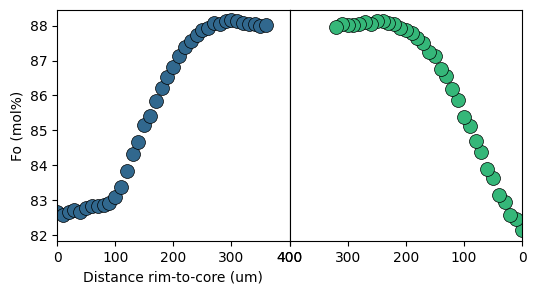

In [101]:
# Define datasets
datasets = [KD24_ols_profiles_Kendra[KD24_ols_profiles_Kendra['  SAMPLE'].str.contains("trav1")],KD24_ols_profiles_Kendra[KD24_ols_profiles_Kendra['  SAMPLE'].str.contains("trav2")]]
titles = ["Traverse 1", 
          "Traverse 2"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("viridis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(6, 3), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    ax.scatter(x=data[' RELDIST'],y=data['Fo'],marker='o',s=100,linewidths=0.5,edgecolors='k',color=ann_color)
    # sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # # Set y-axis properties
    # ax.set_ylim([10,0])  # Inverted y-axis
  # Inverted y-axis
    if i == 0:
        ax.set_xlabel('Distance rim-to-core (um)')
        ax.set_ylabel('Fo (mol%)')
        ax.set_xlim([0,400])
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.set_xlim([400,0])

    
    # Add title and annotation
    fontsize = 9

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Ol33_Dec24_profile.pdf', format='pdf', dpi=300, transparent=False)


In [102]:
K24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"3087-1_Lynn_2020Kilauea_DataTables_01122024.xlsx",sheet_name="Ol 2",skiprows=2)

K24_ols_profiles_Kendra =K24_ols_profiles_Kendra.loc[:, ~K24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(K24_ols_profiles_Kendra.tail(6).index)

# K24_ols_profiles_Kendra=K24_ols_profiles_Kendra[K24_ols_profiles_Kendra['Valid']==1]
K24_ols_profiles_Kendra

,SAMPLE,Distance (μm),SiO2,FeO,MgO,CaO,MnO,NiO,Total,Fo,Initial,Model
0,KS20-527_2-transect,300.8810,39.9520,11.2012,48.1396,0.216475,0.130430,0.397643,100.037348,88.4540,88.5,88.5000
1,KS20-527_2-transect,290.9940,39.7974,11.1398,47.9763,0.216333,0.134179,0.396817,99.660829,88.4755,88.5,88.5000
2,KS20-527_2-transect,280.9190,40.1258,11.2474,47.9028,0.225756,0.135212,0.402800,100.039768,88.3614,88.5,88.5000
3,KS20-527_2-transect,270.8490,39.8987,11.1601,47.7998,0.219193,0.143057,0.389587,99.610437,88.4192,88.5,88.5000
4,KS20-527_2-transect,260.9180,39.8779,11.1485,47.9014,0.218444,0.164312,0.397462,99.708018,88.4516,88.5,88.5000
5,KS20-527_2-transect,250.9750,39.8426,11.5480,48.0378,0.224399,0.142874,0.380431,100.176104,88.1169,88.5,88.5000
6,KS20-527_2-transect,240.9960,40.0614,11.2067,48.0568,0.226257,0.132814,0.418380,100.102351,88.4315,88.5,88.5000
7,KS20-527_2-transect,231.0130,39.8648,11.2801,47.9306,0.218413,0.159855,0.373661,99.827429,88.3374,88.5,88.5000
8,KS20-527_2-transect,220.9020,39.9891,11.0021,48.0294,0.222793,0.126736,0.390365,99.760494,88.6128,88.5,88.5000
9,KS20-527_2-transect,210.8780,39.9234,11.1828,47.9526,0.230127,0.167136,0.398491,99.854554,88.4311,88.5,88.5000


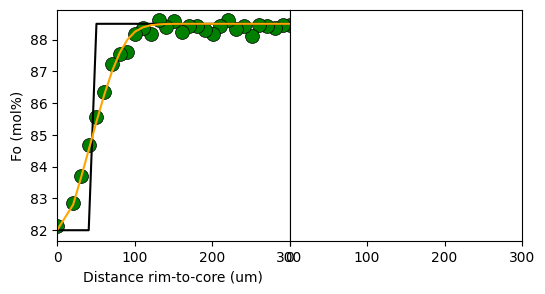

In [103]:
# Define datasets
datasets = [K24_ols_profiles_Kendra,K24_ols_profiles_Kendra]
titles = ["Fo", 
          "Ni, Ca"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("viridis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(6, 3), sharey=False)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    if i==0:
        ax.scatter(x=data['Distance (μm)'],y=data['Fo'],marker='o',s=100,linewidths=0.5,edgecolors='k',color='green')
        ax.plot(data['Distance (μm)'],data['Initial'],color='k')
        ax.plot(data['Distance (μm)'],data['Model'],color='orange')
    # else:
        # ax.scatter(x=data['Distance (μm)'],y=data[' CaO WT%'],marker='s',s=100,linewidths=0.5,edgecolors='k',color='orange')
        # ax.scatter(x=data['Distance (μm)'],y=data[' NiO WT%'],marker='d',s=100,linewidths=0.5,edgecolors='k',color='midnightblue')
    # sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # # Set y-axis properties
    # ax.set_ylim([10,0])  # Inverted y-axis
  # Inverted y-axis
    if i == 0:
        ax.set_xlabel('Distance rim-to-core (um)')
        ax.set_ylabel('Fo (mol%)')
        ax.set_xlim([0,300])
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.set_xlim([0,300])

    
    # Add title and annotation
    fontsize = 9

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Ol2_Dec20_profile.pdf', format='pdf', dpi=300, transparent=False)


In [104]:
K24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"3087-1_Lynn_2020Kilauea_DataTables_01122024.xlsx",sheet_name="S1 Timescales Summary",skiprows=2)
K24_ols_profiles_Kendra =K24_ols_profiles_Kendra.loc[:, ~K24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(K24_ols_profiles_Kendra.tail(6).index)

# K24_ols_profiles_Kendra=K24_ols_profiles_Kendra[K24_ols_profiles_Kendra['Valid']==1]
K24_ols_profiles_Kendra


,Olivine ID,Zoning Type,Ci,Co,t (days),± (days)
0,1,Normal,88.5,82.4,187.0,56.0
1,2,Normal,88.5,82.0,30.0,9.0
2,3,Normal,87.5,82.0,64.0,19.0
3,5,Normal,87.9,82.4,238.0,71.0
4,7,Normal,88,82.3,43.0,13.0
5,10,Normal,88.2,82.0,326.0,98.0
6,11,Normal,87.8,83.4,39.0,12.0
7,12,Normal,88,82.7,51.0,15.0
8,13,Normal,88.2,83.0,60.0,18.0
9,15,Normal,88,83.1,521.0,156.0


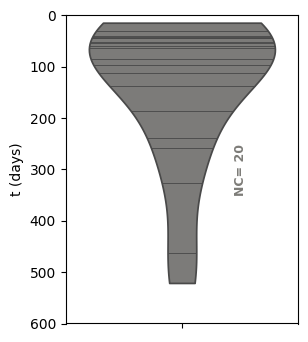

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define datasets
datasets = [K24_ols_profiles_Kendra]  # Can have more datasets, but for now let's assume one
titles = ["SWRZ\n(Dec 1974)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(3, 4), sharey=True)

# If there's only one axis, make it iterable (like a list)
if num_axes == 1:
    axes = [axes]

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['t (days)'], color=ann_color, inner='stick', ax=ax, cut=0,)
    
    ax.set_ylim([600,0])
    if i == 0:
        ax.set_ylabel('t (days)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    # ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
    #             ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {len(data[(data['t (days)'].notna())])}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots

fig.savefig(figpath + slash + 'Dec20_Kendra_Ol_violin_plot.pdf', format='pdf', dpi=300, transparent=False)


# UP TO HERE I CLEANED UP ON JAN 30 2025

## Lets get the equilibrium Olivine Fo contents here 

In [28]:
import Thermobar as pt

In [30]:
Ulu_MG_input=pt.import_excel(r"C:\Users\charl\Documents\Python dev\PrePostCalderaKil_2025\Version_on_pcloud\Data\Data_SWRZ\1974_olivine_glass_data\UluData.xlsx",
                         sheet_name='Matrix Glass')
Ulu_all=Ulu_MG_input['my_input'] ## All columns
Ulu_Liqs_all=Ulu_MG_input['Liqs'] ## Just Liquid columns
Ulu_Liqs_19=Ulu_Liqs_all.loc[Ulu_all['Eruption']==919]
Ulu_Liqs_19.head()
Mean_19=np.mean(Ulu_Liqs_19)

In [41]:
## Glasses 


K24_MG_input=pt.import_excel(r"C:\Users\charl\Documents\Python dev\PrePostCalderaKil_2025\Version_on_pcloud\Data_processing_notebooks\Data_processing_SWRZ\Notebook_Compiled_data\GlassData2024.xlsx",
                         sheet_name='Sheet1', suffix='_Liq')
K24_all=K24_MG_input['my_input'] ## All columns
K24_Liqs_all=K24_MG_input['Liqs'][3:9] ## Just Liquid columns
Liq_Mean_24=np.mean(K24_Liqs_all)

In [42]:
Eq_Ol_19=pt.calculate_eq_ol_content(liq_comps=Ulu_Liqs_19, Kd_model="Shea2022",Fe3Fet_Liq=0.18)
Eq_Ol_24=pt.calculate_eq_ol_content(liq_comps=K24_Liqs_all, Kd_model="Shea2022",Fe3Fet_Liq=0.18)

In [43]:
np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.335)'])

0.834256220498497

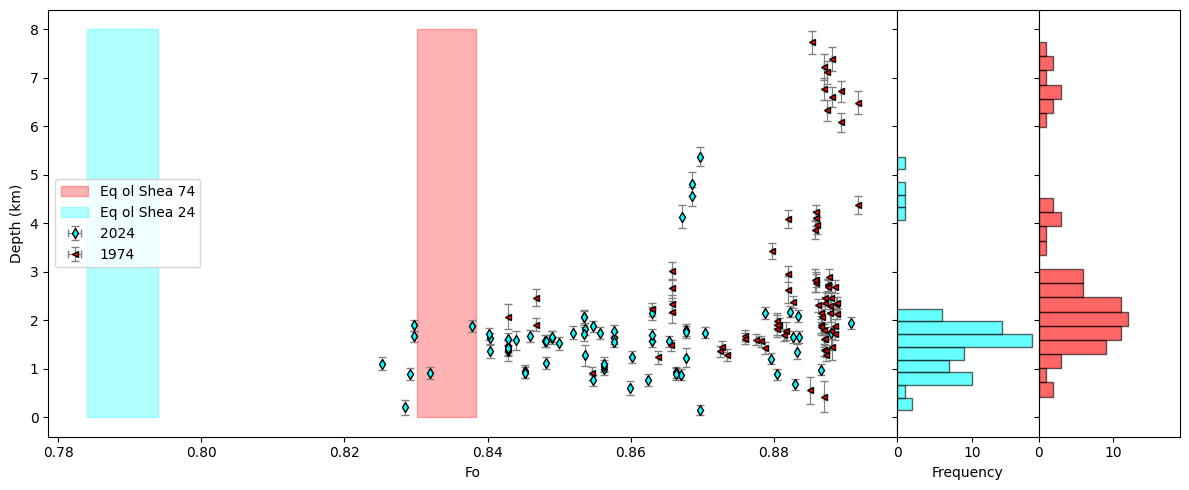

In [62]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[3, 0.5, 0.5], wspace=0)

ax1 = plt.subplot(gs[0])

# Calculate x coordinates and plot rectangles for Eq_Ol_19
x1 = np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.325)'])
x2 = np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.345)'])
ax1.fill_betweenx(y=[0, 8], x1=x1, x2=x2, color='red', alpha=0.3, label='Eq ol Shea 74')

# Calculate x coordinates and plot rectangles for Eq_Ol_24
x1 = np.mean(Eq_Ol_24['Eq Fo (Shea, Kd=0.325)'])
x2 = np.mean(Eq_Ol_24['Eq Fo (Shea, Kd=0.345)'])
ax1.fill_betweenx(y=[0, 8], x1=x1, x2=x2, color='cyan', alpha=0.3, label='Eq ol Shea 24')

# Plot error bars
ax1.errorbar(df_combo['Fo'].loc[K24], MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[K24], xerr=0, yerr=MC_Av_rho_T_df_B['std_dev_MC_D_km_from_percentile'].loc[K24],
             fmt='d', ecolor='grey', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='2024')
ax1.errorbar(df_combo['Fo'].loc[U919], MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[U919], xerr=0, yerr=MC_Av_rho_T_df_B['std_dev_MC_D_km_from_percentile'].loc[U919],
             fmt='<', ecolor='grey', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='1974')

ax1.set_xlabel('Fo')
ax1.set_ylabel('Depth (km)')
ax1.legend()

# Histogram plot
ax2 = plt.subplot(gs[1], sharey=ax1)
ax3 = plt.subplot(gs[2], sharey=ax1, sharex=ax2)
ax2.hist(MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[K24], bins=20, stacked=True, orientation='horizontal', color=['cyan'], ec='k', alpha=0.6)
ax3.hist(MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[U919], bins=25, stacked=True, orientation='horizontal', color=['red'], ec='k', alpha=0.6)

ax2.set_xlabel('Frequency')
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.tight_layout()
fig.savefig('FoDepth.png', dpi=300)
plt.show()